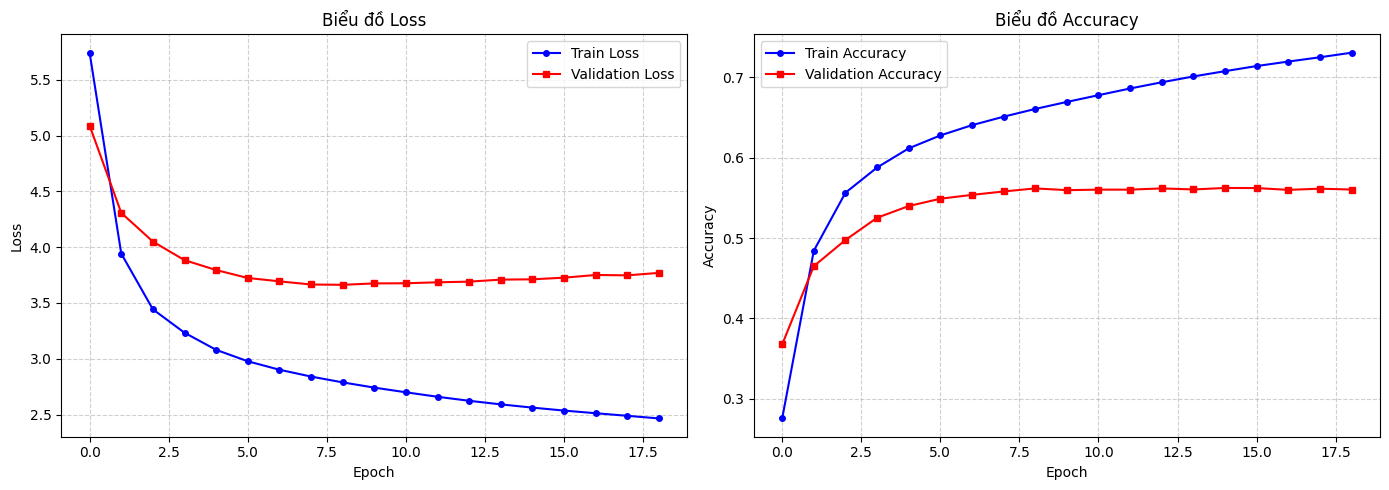

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = '../report/training_history.csv'

try:
    history = pd.read_csv(file_path)
    
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    epochs = range(len(history))
    plt.plot(epochs, history['loss'], label='Train Loss', color='blue', marker='o', markersize=4)
    if 'val_loss' in history.columns:
        plt.plot(epochs, history['val_loss'], label='Validation Loss', color='red', marker='s', markersize=4)
    
    plt.title('Biểu đồ Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    acc_col = 'masked_accuracy' if 'masked_accuracy' in history.columns else 'accuracy'
    val_acc_col = 'val_masked_accuracy' if 'val_masked_accuracy' in history.columns else 'val_accuracy'

    plt.subplot(1, 2, 2)
    if acc_col in history.columns:
        plt.plot(epochs, history[acc_col], label='Train Accuracy', color='blue', marker='o', markersize=4)
    if val_acc_col in history.columns:
        plt.plot(epochs, history[val_acc_col], label='Validation Accuracy', color='red', marker='s', markersize=4)
    
    plt.title('Biểu đồ Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Không tìm thấy file tại: {file_path}")

In [3]:
import tensorflow as tf
import yaml
import sentencepiece as spm
import nltk
from nltk.translate.bleu_score import corpus_bleu
import sys

sys.path.append('../')
from models.transformer import Transformer
from utils.dataset_pipeline import TranslationDataset

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

2026-08-02 00:09:38.484420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785629378.724047      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785629378.788277      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785629379.324032      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785629379.324079      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785629379.324083      23 computation_placer.cc:177] computation placer alr

In [4]:
with open('../config.yaml','r',encoding='utf-8') as f:
    config=yaml.safe_load(f)
    
EN_SPM_PATH = '../data/tokenizer/spm_en.model'
VI_SPM_PATH = '../data/tokenizer/spm_vi.model'
TEST_TFRECORD = '../data/test.tfrecord'

sp_en=spm.SentencePieceProcessor(model_file=EN_SPM_PATH)
sp_vi=spm.SentencePieceProcessor(model_file=VI_SPM_PATH)

dataset_builder=TranslationDataset(
    max_length=config['MAX_LENGTH'],
    batch_size=config['BATCH_SIZE']//2
)

VAL_TFRECORD = '../data/val.tfrecord'
val_ds = dataset_builder.create_dataset(VAL_TFRECORD)

model = Transformer(
    num_layers=config["NUM_LAYERS"],
    num_heads=config["NUM_HEADS"],
    d_model=config["D_MODEL"],
    dff=config["DFF"],
    input_vocab_size=sp_en.get_piece_size(),
    tgt_vocab_size=sp_vi.get_piece_size()
)

for (en_batch, vi_inp_batch), vi_real_batch in val_ds.take(1):
    _ = model((en_batch, vi_inp_batch), training=False)
    
model.load_weights('../checkpoints/transformer_best_model.weights.h5')

I0000 00:00:1785629396.069434      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encod

In [6]:
from tqdm import tqdm
from pyvi import ViTokenizer
import numpy as np

PAD_ID=0
BOS_ID=2
EOS_ID=3

def batch_beam_search_decode(encoder_input,beam_width=4,len_penalty_alpha=0.6):
    batch_size=tf.shape(encoder_input)[0]
    max_len=config["MAX_LENGTH"]

    # # [batch_size, len_en] -> [batch_size * beam_width, len_en]
    tiled_encoder_input=tf.repeat(encoder_input,repeats=beam_width,axis=0)

    beams=tf.fill([batch_size,beam_width,1],BOS_ID)

    init_log_probs=tf.constant([[0.0]+[-1e9]*(beam_width-1)],dtype=tf.float32)
    beam_log_probs=tf.tile(init_log_probs,[batch_size,1])

    finished=tf.fill([batch_size,beam_width],False)

    for step in range(max_len-1):
        if tf.reduce_all(finished):
            break

        seq_len=tf.shape(beams)[2]

        # [batch_size * beam_width, seq_len]
        decoder_input=tf.reshape(beams,[batch_size*beam_width,seq_len])

        predictions=model((tiled_encoder_input,decoder_input),training=False)
        last_logits=predictions[:,-1,:] # [batch_size * beam_width, vocab_size]

        vocab_size=tf.shape(last_logits)[-1]

        step_log_probs=tf.nn.log_softmax(last_logits) # [batch_size  * beam_width, vocab _size]
        step_log_probs=tf.reshape(step_log_probs,[batch_size,beam_width,vocab_size])

        # Nếu chùm đã kết thúc (gặp EOS), từ tiếp theo bắt buộc là PAD_ID (0) với xác suất log = 0.0, từ khác = -1e9
        finished_expand=finished[:,:,tf.newaxis]
        finished_log_probs=(1.0-tf.one_hot(PAD_ID,depth=vocab_size))*(-1e9)
        step_log_probs=tf.where(finished_expand,finished_log_probs,step_log_probs)

        # [batch_size, beam_width, vocab_size]
        total_log_probs=beam_log_probs[:,:,tf.newaxis]+step_log_probs

        # [batch_size, beam_width * vocab_size]
        total_log_probs_flat=tf.reshape(total_log_probs,[batch_size,-1])
        top_log_probs, top_indices=tf.math.top_k(total_log_probs_flat,k=beam_width) # [batch_size, beam_width]

        parent_beam_idx=tf.math.floordiv(top_indices,vocab_size) # chia lấy nguyên để lấy beam
        token_id=tf.math.mod(top_indices,vocab_size) # chia lấy dư để lấy token_id

        # [batch_size, beam_width, seq_len]
        batch_idx=tf.tile(tf.range(batch_size)[:,tf.newaxis],[1,beam_width])
        gather_indices=tf.stack([batch_idx,parent_beam_idx],axis=-1)
        parent_beams=tf.gather_nd(beams,gather_indices)

        beams=tf.concat([parent_beams,token_id[:,:,tf.newaxis]],axis=-1)

        # [batch_size,beam_width]
        parent_finished=tf.gather_nd(finished,gather_indices)
        finished=tf.logical_or(parent_finished,tf.equal(token_id,EOS_ID))
        beam_log_probs=top_log_probs

    is_content=tf.logical_not(tf.reduce_any(tf.stack([
        tf.equal(beams,PAD_ID),
        tf.equal(beams,EOS_ID),
        tf.equal(beams,BOS_ID)
    ],axis=0),axis=0))
    lengths=tf.reduce_sum(tf.cast(is_content,tf.float32),axis=-1)

    penalties=((5.0+lengths)**len_penalty_alpha)/((5.0+1.0)**len_penalty_alpha)
    scores=beam_log_probs/penalties

    best_beam_idx=tf.argmax(scores,axis=-1)
    gather_best_indices=tf.stack([tf.range(batch_size), tf.cast(best_beam_idx, tf.int32)], axis=-1)
    best_beams=tf.gather_nd(beams,gather_best_indices)

    best_beams_np = best_beams.numpy()
    result_batch_ids = []
    for i in range(best_beams_np.shape[0]):
        raw_ids=best_beams_np[i].tolist()
        clean_ids=[t for t in raw_ids if t not in [PAD_ID,EOS_ID,BOS_ID]]
        result_batch_ids.append(clean_ids)
    
    return result_batch_ids

In [7]:
def evaluate_batch_beam(dataset, limit=None, beam_width=4, len_penalty_alpha=0.6):
    hypotheses = []
    references = []
    
    dataset_to_eval = dataset.take(limit) if limit else dataset
    
    for (en_batch, vi_inp_batch), vi_real_batch in tqdm(dataset_to_eval):
        pred_batch_ids = batch_beam_search_decode(en_batch, beam_width=beam_width, len_penalty_alpha=alpha)
        
        batch_size_current = len(en_batch)
        for i in range(batch_size_current):
            # Nhãn chuẩn (reference)
            vi_real_ids = vi_real_batch[i].numpy().tolist()
            vi_ids = [t for t in vi_real_ids if t not in [PAD_ID, EOS_ID, BOS_ID]]
            vi_s = sp_vi.decode(vi_ids)
            
            if not vi_s.strip():
                continue
            
            pred = sp_vi.decode(pred_batch_ids[i])
            
            ref_segmented = ViTokenizer.tokenize(vi_s.lower())
            hyp_segmented = ViTokenizer.tokenize(pred.lower())
            hypotheses.append(hyp_segmented.split())
            references.append([ref_segmented.split()])

    bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0.0, 0.0, 0.0))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0.0, 0.0))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    print(f"Beam_width: {beam_width}, alpha: {len_penalty_alpha}")
    print(f"Tổng số mẫu đánh giá : {len(hypotheses)} câu")
    print(f"BLEU-1 Score         : {bleu1*100:.2f} / 100")
    print(f"BLEU-2 Score         : {bleu2*100:.2f} / 100")
    print(f"BLEU-4 Score (Chuẩn) : {bleu4*100:.2f} / 100")
    return bleu4

In [8]:
beam_widths = [4, 5, 6]
alphas = [0.5, 0.6, 0.7, 0.8]
beam_width_max=beam_widths[0]
alpha_max=alphas[0]
bleu4_max=0.0000

for beam_width in beam_widths:
    for alpha in alphas: 
        bleu4=evaluate_batch_beam(val_ds,limit=25,beam_width=beam_width,len_penalty_alpha=alpha)
        if bleu4>bleu4_max:
            beam_width_max=beam_width
            alpha_max=alpha
            bleu4_max=bleu4

print(f"Max BLEU-4 Score: {bleu4_max}")
print(f"-> Beam_width: {beam_width_max}")
print(f"-> Alpha: {alpha_max}")

25it [05:59, 14.38s/it]


Beam_width: 4, alpha: 0.5
Tổng số mẫu đánh giá : 600 câu
BLEU-1 Score         : 52.93 / 100
BLEU-2 Score         : 37.34 / 100
BLEU-4 Score (Chuẩn) : 20.25 / 100


25it [05:58, 14.34s/it]


Beam_width: 4, alpha: 0.6
Tổng số mẫu đánh giá : 600 câu
BLEU-1 Score         : 53.04 / 100
BLEU-2 Score         : 37.46 / 100
BLEU-4 Score (Chuẩn) : 20.33 / 100


25it [05:57, 14.31s/it]


...

Beam_width: 6, alpha: 0.6
Tổng số mẫu đánh giá : 600 câu
BLEU-1 Score         : 53.20 / 100
BLEU-2 Score         : 37.53 / 100
BLEU-4 Score (Chuẩn) : 20.35 / 100


25it [06:50, 16.42s/it]


Beam_width: 6, alpha: 0.7
Tổng số mẫu đánh giá : 600 câu
BLEU-1 Score         : 53.52 / 100
BLEU-2 Score         : 37.73 / 100
BLEU-4 Score (Chuẩn) : 20.47 / 100


25it [06:49, 16.37s/it]


Beam_width: 6, alpha: 0.8
Tổng số mẫu đánh giá : 600 câu
BLEU-1 Score         : 53.74 / 100
BLEU-2 Score         : 37.95 / 100
BLEU-4 Score (Chuẩn) : 20.60 / 100
Max BLEU-4 Score: 0.20720667348082913
-> Beam_width: 5
-> Alpha: 0.8


In [9]:
import gc

tf.keras.backend.clear_session()
gc.collect()

0

In [10]:
test_ds=dataset_builder.create_dataset(TEST_TFRECORD)

_=evaluate_batch_beam(test_ds,limit=500,beam_width=beam_width_max,len_penalty_alpha=alpha_max)

500it [1:27:20, 10.48s/it]


Beam_width: 5, alpha: 0.8
Tổng số mẫu đánh giá : 12000 câu
BLEU-1 Score         : 52.58 / 100
BLEU-2 Score         : 36.21 / 100
BLEU-4 Score (Chuẩn) : 19.07 / 100
